## Static load comparison: mean wind vs 30 s constant gust

**Old static** (`*run{N}-1.h5`): equilibrium under mean wind speed (U10)

**New static** (`*run{N}.h5`): equilibrium under constant 30 s wind gust (U30s)

Wind redistributes loads between mooring lines and fenders — this notebook quantifies that redistribution per element, condition, and heading.

In [ ]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

# Resolve this notebook's folder (works in VS Code and standard Jupyter)
BASE     = Path(globals().get('__vsc_ipynb_file__', Path.cwd() / '_')).parent
HEADINGS = ["0deg", "45deg", "90deg", "135deg", "180deg"]

MOORINGS = [f"Mooring{i}" for i in range(1, 9)]
FENDERS  = [f"Fender{i}"  for i in range(1, 7)]
ELEMENTS = MOORINGS + FENDERS

HL_RUN = {
    "HL7":  1,  "HL9":  2,  "HL11": 3,  "HL13": 4,
    "HL15": 5,  "HL17": 6,  "HL19": 7,  "HL21": 8,
    "HL23": 9,  "HL25": 10, "HL27": 11, "HL29": 12,
}

U10_PER_COND = [4.49, 5.79, 6.87, 7.77, 8.59, 9.35, 10.04, 10.68, 11.31]

In [2]:
def read_static(fpath, run_n):
    result = {}
    with h5py.File(fpath, "r") as f:
        root      = list(f.keys())[0]
        run_group = f[f"{root}/Run{run_n}"]
        for cond_key in sorted(run_group.keys()):
            result[cond_key] = {
                e: f[f"{root}/Run{run_n}/{cond_key}/Static/Tanker/{e}/FTotal"][()] / 1e3
                for e in ELEMENTS
            }
    return result


records = []

for heading in HEADINGS:
    for hl, run_n in HL_RUN.items():
        old_path = BASE / heading / hl / f"StaticResults_{hl}_run{run_n}-1.h5"
        new_path = BASE / heading / hl / f"StaticResults_{hl}_run{run_n}.h5"

        if not old_path.exists() or not new_path.exists():
            continue

        old_data = read_static(old_path, run_n)
        new_data = read_static(new_path, run_n)

        for cond_idx, (cond_key, old_elems) in enumerate(old_data.items()):
            u10 = U10_PER_COND[cond_idx] if cond_idx < len(U10_PER_COND) else np.nan
            new_elems = new_data[cond_key]
            for elem in ELEMENTS:
                vo = old_elems[elem]
                vn = new_elems[elem]
                records.append({
                    "Heading":   heading,
                    "HL":        hl,
                    "Condition": cond_key,
                    "U10":       u10,
                    "Element":   elem,
                    "Old [kN]":  round(vo, 3),
                    "New [kN]":  round(vn, 3),
                    "Diff [kN]": round(vn - vo, 3),
                    "Diff [%]":  round((vn - vo) / vo * 100, 3) if vo else np.nan,
                })

df = pd.DataFrame(records)
print(f"Total records: {len(df)}")
df.head(14)

Total records: 7210


,Heading,HL,Condition,U10,Element,Old [kN],New [kN],Diff [kN],Diff [%]
0,0deg,HL7,Run1_1,4.49,Mooring1,158.324,158.929,0.605,0.382
1,0deg,HL7,Run1_1,4.49,Mooring2,146.252,146.712,0.460,0.314
2,0deg,HL7,Run1_1,4.49,Mooring3,141.032,141.008,-0.024,-0.017
3,0deg,HL7,Run1_1,4.49,Mooring4,159.433,158.668,-0.765,-0.480
4,0deg,HL7,Run1_1,4.49,Mooring5,163.300,163.636,0.336,0.206
5,0deg,HL7,Run1_1,4.49,Mooring6,143.431,143.380,-0.051,-0.035
6,0deg,HL7,Run1_1,4.49,Mooring7,147.220,146.679,-0.542,-0.368
7,0deg,HL7,Run1_1,4.49,Mooring8,157.654,157.005,-0.649,-0.411
8,0deg,HL7,Run1_1,4.49,Fender1,136.113,134.994,-1.119,-0.822
9,0deg,HL7,Run1_1,4.49,Fender2,134.559,133.903,-0.656,-0.487


## Maximum change per element across all conditions and headings

In [3]:
summary = (
    df.groupby("Element")[["Diff [kN]", "Diff [%]"]]
    .agg(
        max_abs_kN=("Diff [kN]",  lambda x: x.abs().max()),
        max_pct    =("Diff [%]",   "max"),
        min_pct    =("Diff [%]",   "min"),
    )
    .reindex(ELEMENTS)
    .round(3)
)
summary

,max_abs_kN,max_pct,min_pct
Element,,,
Mooring1,11.819,6.639,-5.125
Mooring2,15.418,2.834,-12.712
Mooring3,8.507,2.438,-7.343
Mooring4,19.570,3.946,-15.159
Mooring5,8.770,4.972,-2.123
Mooring6,5.229,3.585,-2.878
Mooring7,5.676,1.403,-4.272
Mooring8,12.368,2.799,-9.098
Fender1,234.818,72.944,-4.185


## % change per element — highest U10 condition (11.31 m/s), all headings

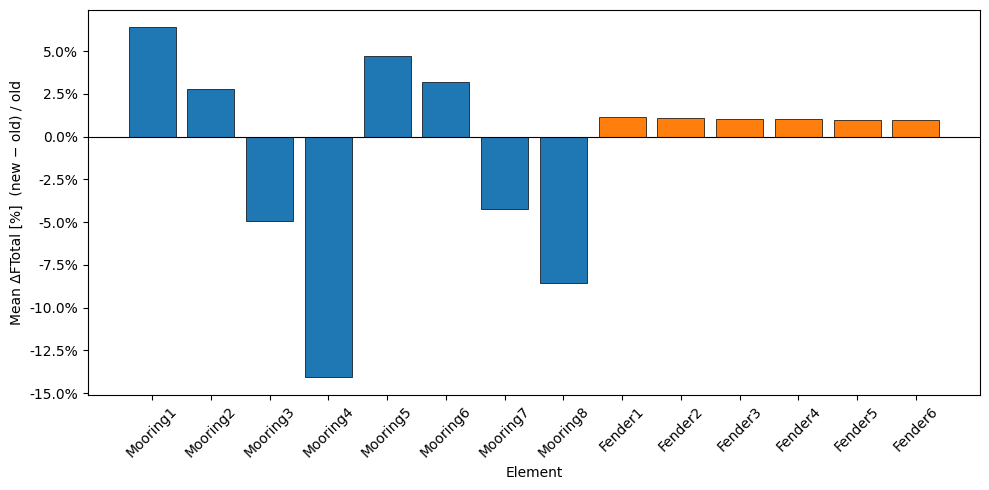

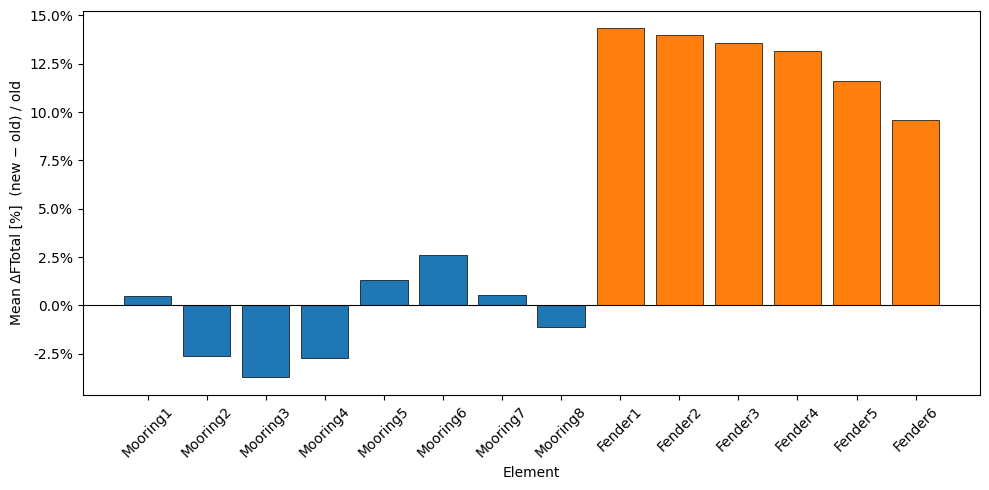

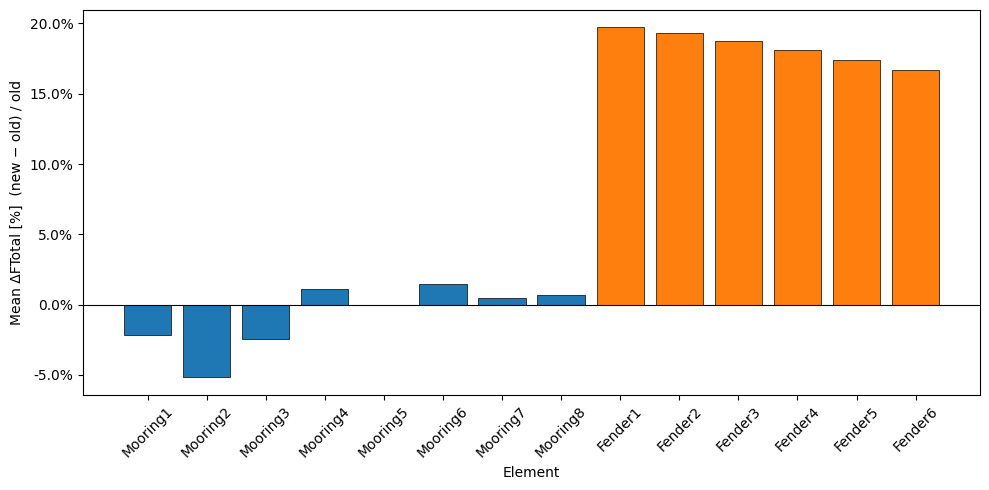

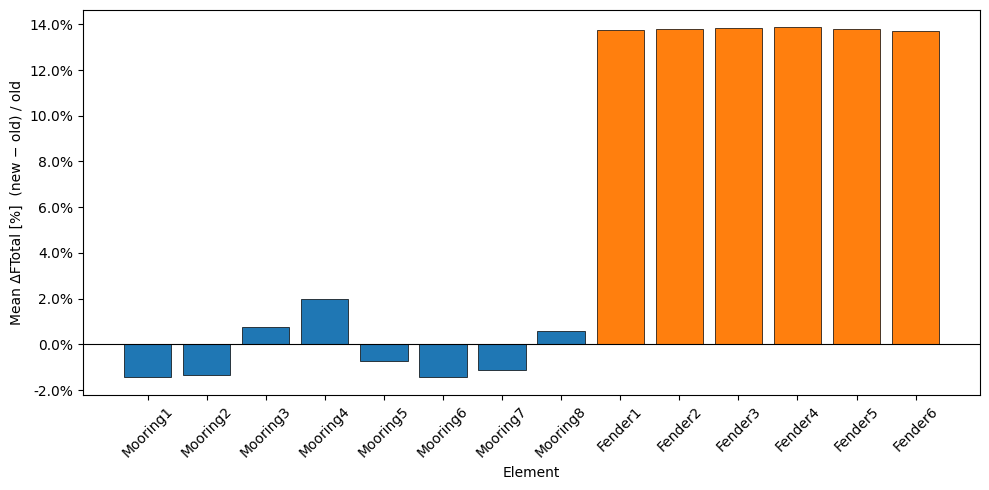

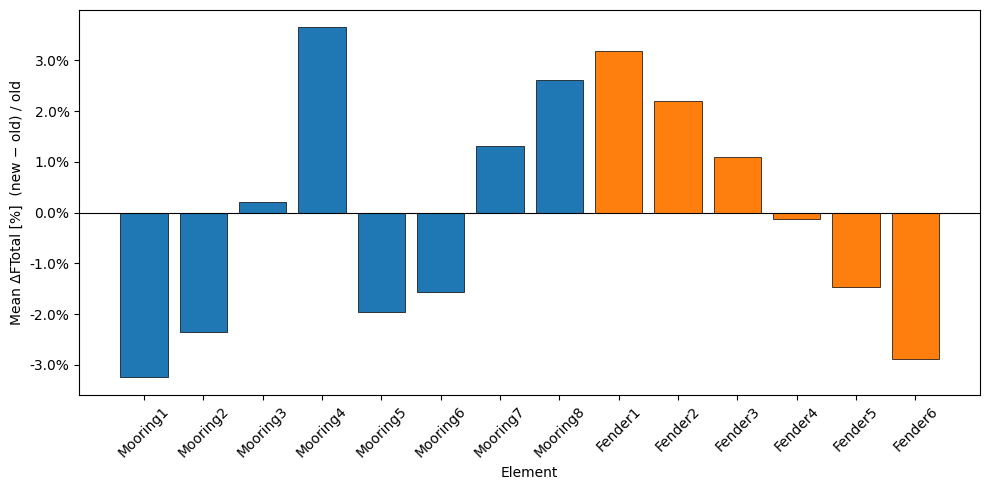

In [4]:
subset = df[df["U10"] == 11.31]

for heading in HEADINGS:
    hdf = subset[subset["Heading"] == heading]
    if hdf.empty:
        continue

    pivot  = hdf.groupby("Element")["Diff [%]"].mean().reindex(ELEMENTS)
    colors = ["#1f77b4"] * 8 + ["#ff7f0e"] * 6

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(ELEMENTS, pivot.values, color=colors, edgecolor="k", linewidth=0.5)
    ax.axhline(0, color="k", linewidth=0.8)
    ax.set_xlabel("Element")
    ax.set_ylabel("Mean ΔFTotal [%]  (new − old) / old")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()

## % change vs U10 for the most affected element (per heading)

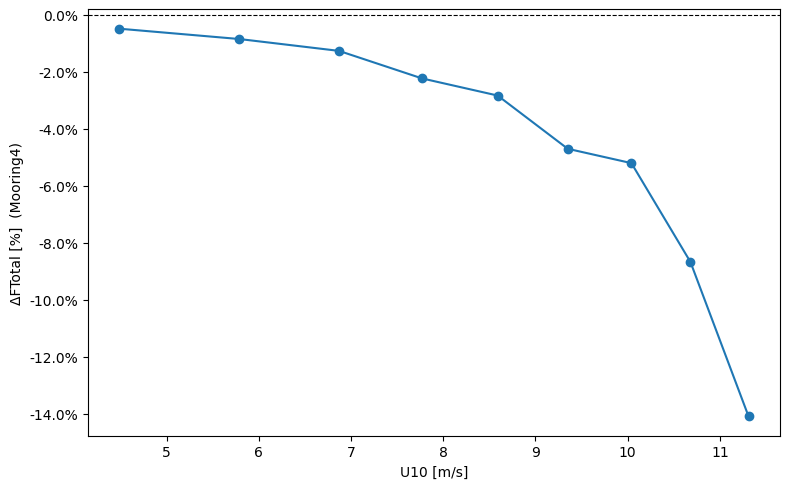

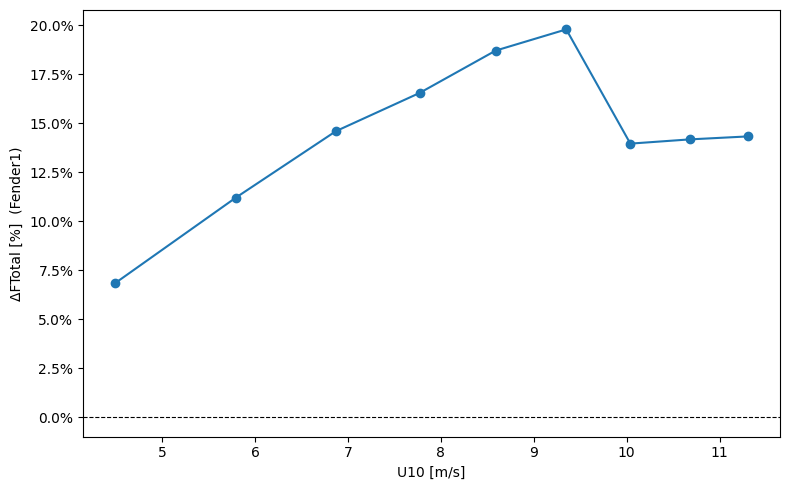

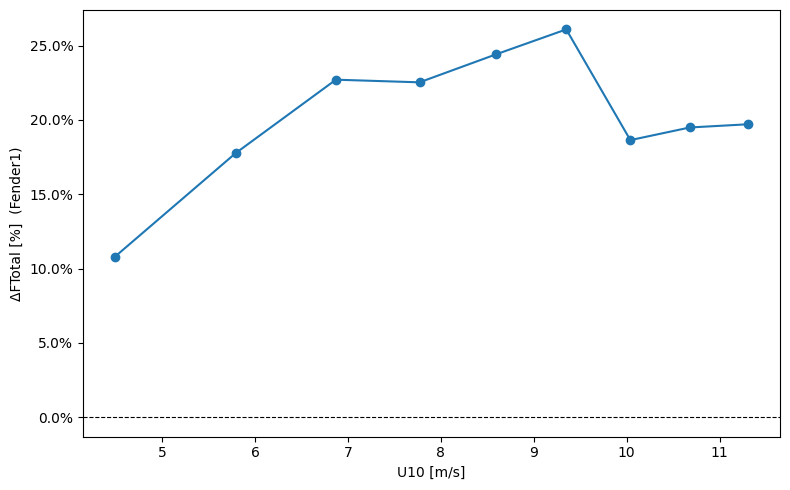

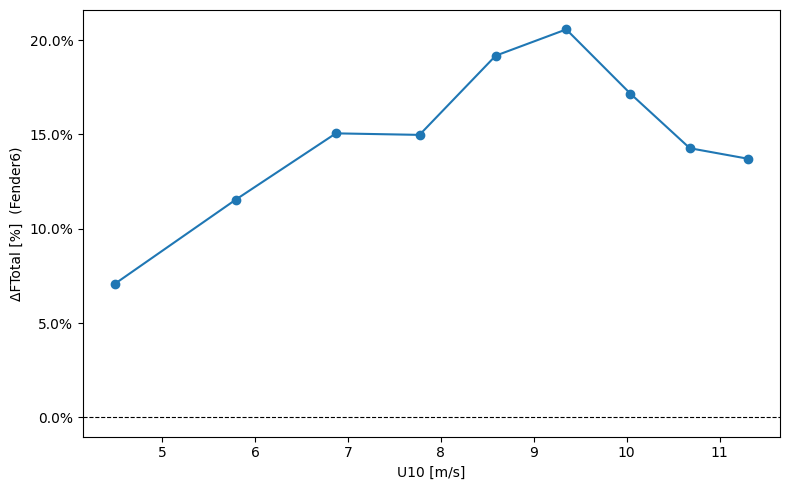

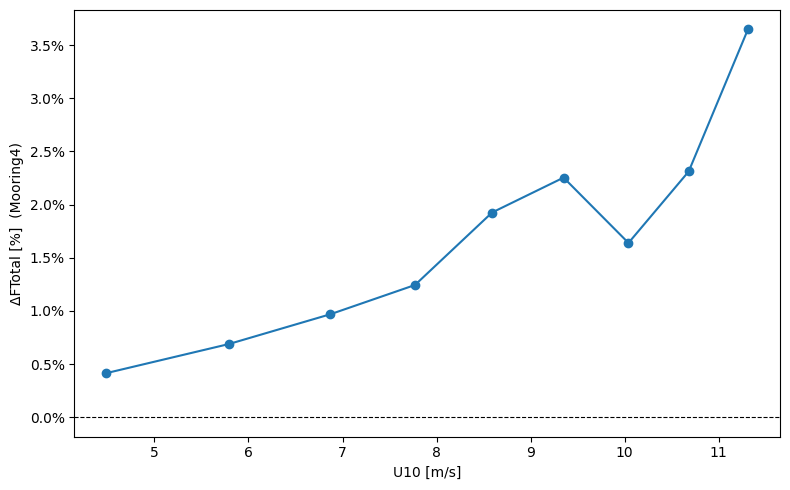

In [5]:
for heading in HEADINGS:
    hdf = df[df["Heading"] == heading]
    if hdf.empty:
        continue

    worst_elem = hdf.groupby("Element")["Diff [%]"].apply(lambda x: x.abs().max()).idxmax()
    edf = (
        hdf[hdf["Element"] == worst_elem]
        .groupby("U10")["Diff [%]"].mean()
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(edf["U10"], edf["Diff [%]"], marker="o", linewidth=1.5)
    ax.axhline(0, color="k", linewidth=0.8, linestyle="--")
    ax.set_xlabel("U10 [m/s]")
    ax.set_ylabel(f"ΔFTotal [%]  ({worst_elem})")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))
    plt.tight_layout()
    plt.show()

## Total mooring and fender force: old vs new, per heading

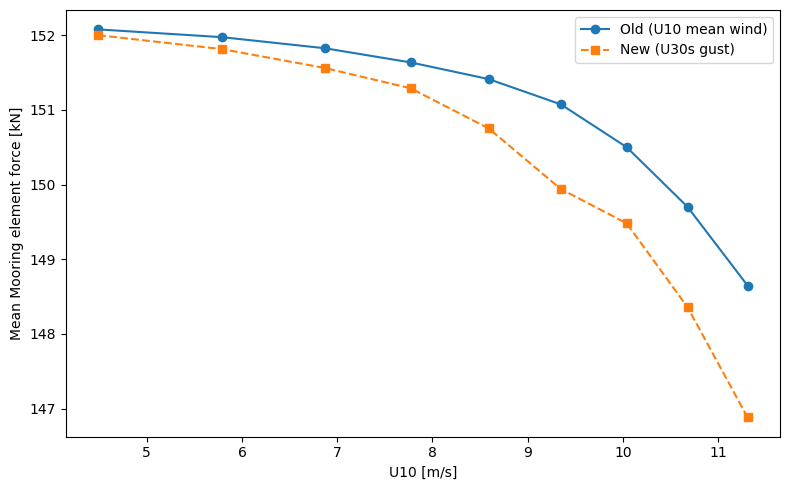

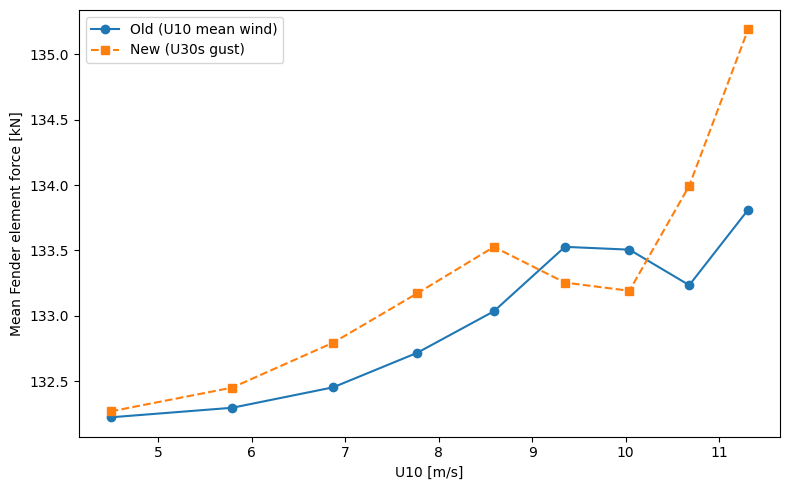

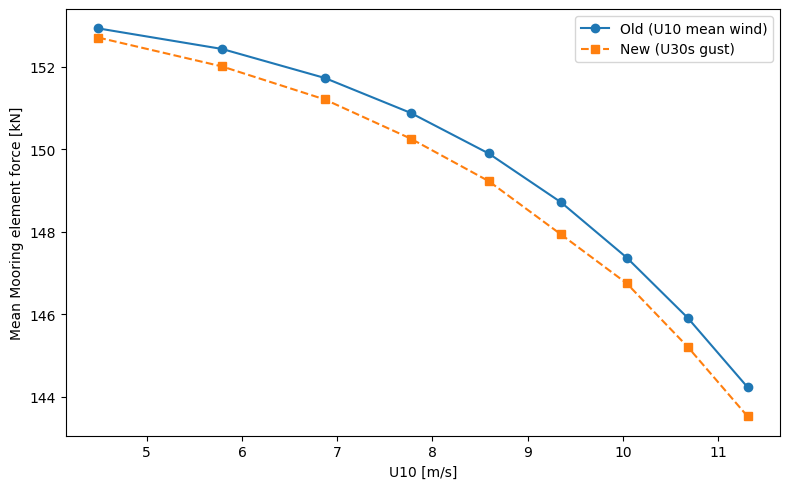

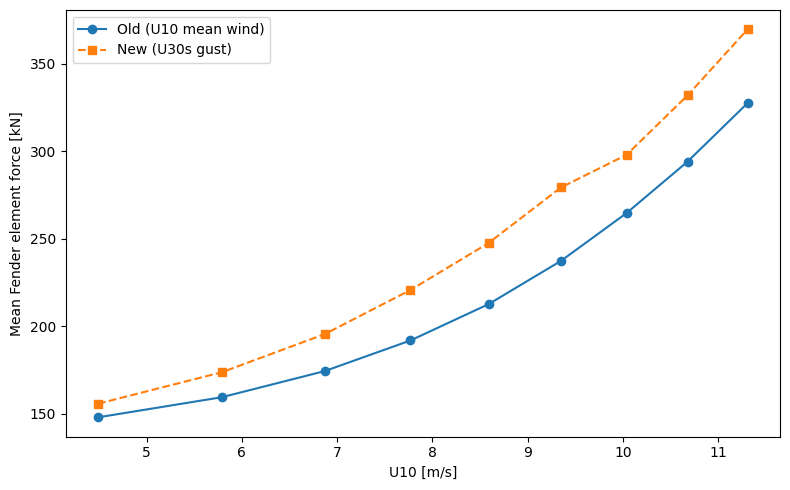

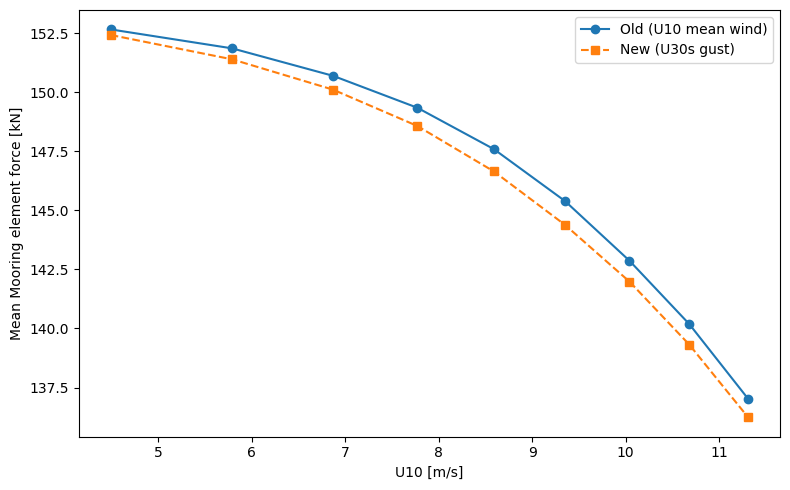

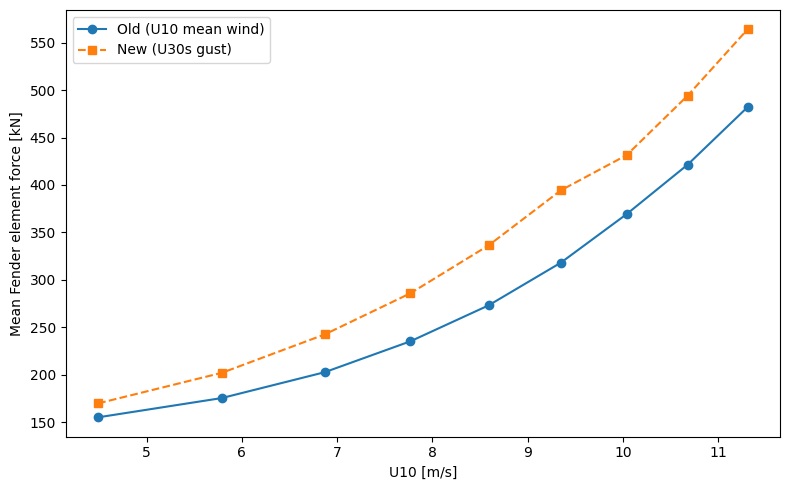

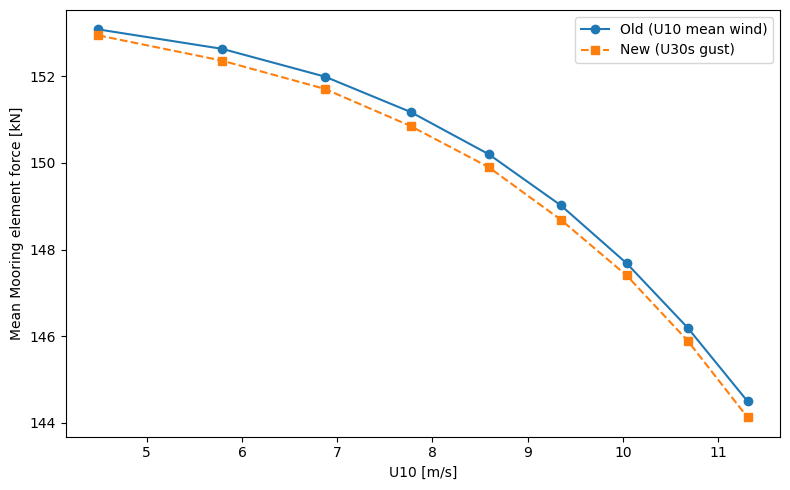

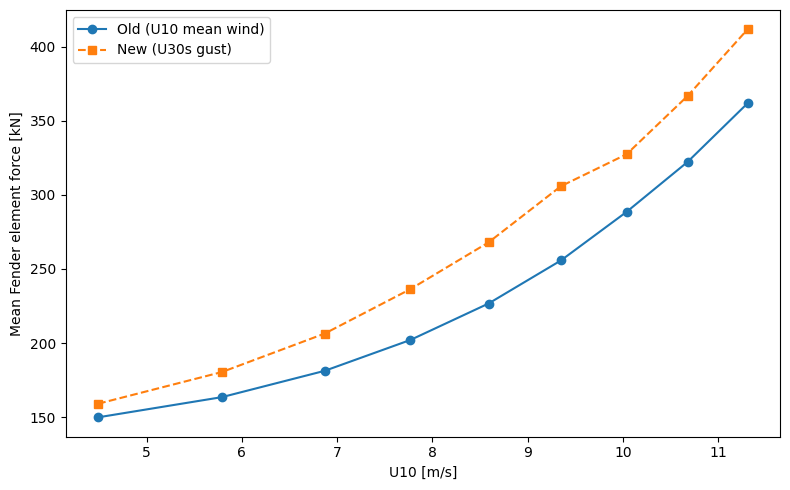

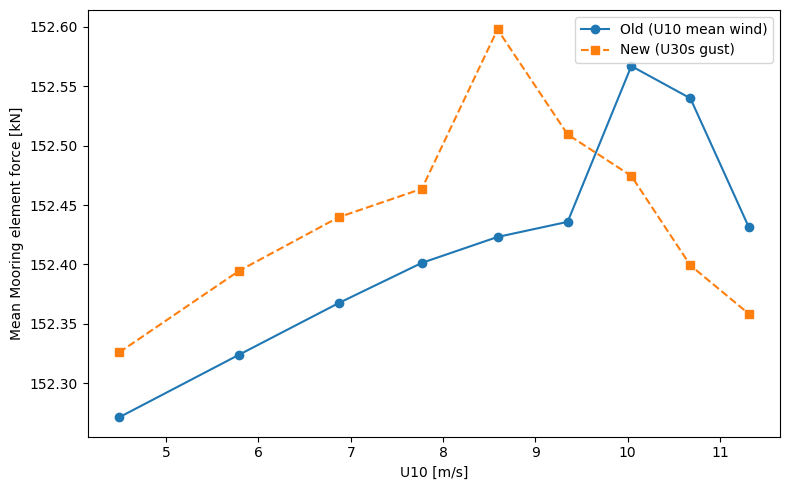

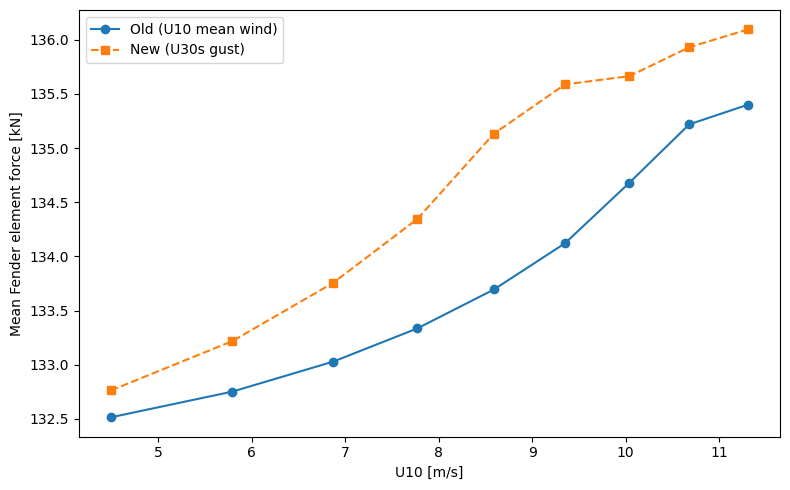

In [6]:
type_map = {e: "Mooring" for e in MOORINGS}
type_map.update({e: "Fender" for e in FENDERS})
df["Type"] = df["Element"].map(type_map)

totals = (
    df.groupby(["Heading", "Type", "U10"])[["Old [kN]", "New [kN]"]]
    .mean()
    .reset_index()
)

for heading in HEADINGS:
    for etype in ["Mooring", "Fender"]:
        grp = totals[(totals["Heading"] == heading) & (totals["Type"] == etype)]
        if grp.empty:
            continue

        fig, ax = plt.subplots(figsize=(8, 5))
        ax.plot(grp["U10"], grp["Old [kN]"], marker="o",
                label="Old (U10 mean wind)", linewidth=1.5)
        ax.plot(grp["U10"], grp["New [kN]"], marker="s", linestyle="--",
                label="New (U30s gust)", linewidth=1.5)
        ax.set_xlabel("U10 [m/s]")
        ax.set_ylabel(f"Mean {etype} element force [kN]")
        ax.legend()
        plt.tight_layout()
        plt.show()